In [1]:
suppressMessages(library(dplyr))
suppressWarnings(suppressMessages(library(lubridate)))
library(tidyr)

# Define column names and classes
names <- c("ProjectID", "License1", "Adoption1", "License2", "Adoption2",
           "Distance","EarliestCommitDate","LatestCommitDate", "Language", "NumAuthors1",
           "NumAuthors2", "NumBlobs1", "NumBlobs2", "NumCommits1", "NumCommits2",
           "NumFiles1", "NumFiles2", "NumActiveMon1", "NumActiveMon2", "UpProjects1",
           "UpProjects2", "DownProjects1", "DownProjects2")

classes <- c("character", "character", "character", "character", "character",
             "integer", "numeric", "numeric", "character", "integer",
             "integer", "integer", "integer", "integer", "integer",
             "integer", "integer", "integer", "integer", "integer",
             "integer", "integer", "integer")

# Load license map
map <- read.table("../data/L2TL.s", sep=";", header=FALSE, col.names=c("L", "TL"), 
                  quote="", comment.char="")

rank_map <- c(
  "public-domain"   = 5,
  "permissive"      = 4,
  "conditional-open"= 3,
  "weak-copyleft"   = 2,
  "copyleft"        = 1
)

# license type proportions
proportions <- read.csv("../data/choice/proportions.csv", check.names = FALSE, stringsAsFactors = FALSE)
proportions <- proportions %>%
    mutate(t = as.Date(sub("-01$", "-15", t)))
# Reshape to long format
proportions_long <- proportions %>%
    pivot_longer(cols = -t, names_to = "LicenseType", values_to = "prop_value")
# 2) Create two labeled versions: one for prop1, one for prop2
prop1_long <- proportions_long %>%
    rename(Adoption = t, LType = LicenseType, prop1 = prop_value)
prop2_long <- proportions_long %>%
    rename(Adoption = t, LType = LicenseType, prop2 = prop_value)


# Define file paths as a character vector
path <- c("../data/choice/cP2all.1y", "../data/choice/cP2all.2y")

# Initialize list to store data
x <- list()

# Loop over files
for (i in seq_along(path)) {
    # Load data
    x[[i]] <- read.table(path[i], sep=";", header=FALSE, col.names=names, 
                         colClasses=classes, quote="", comment.char="")
    
    # Merge to get L1Type and L2Type
    x[[i]] <- x[[i]] %>%
        left_join(map, by=c("License1" = "L")) %>%
        rename(L1Type = TL) %>%
        left_join(map, by=c("License2" = "L")) %>%
        rename(L2Type = TL)
    
    x[[i]][["L1Type"]] <- droplevels(x[[i]][["L1Type"]])
    x[[i]][["L1Type"]] <- relevel(x[[i]][["L1Type"]], ref = "other")
    
    x[[i]][["L2Type"]] <- droplevels(x[[i]][["L2Type"]])
    x[[i]][["L2Type"]] <- relevel(x[[i]][["L2Type"]], ref = "other")
    
    # license change var
    x[[i]][["C"]] <- ifelse(
        x[[i]][["L1Type"]] == "other" | 
        x[[i]][["L2Type"]] == "other" | 
        x[[i]][["L1Type"]] == x[[i]][["L2Type"]],
        "other",
        paste0(x[[i]][["L1Type"]], "2", x[[i]][["L2Type"]]))
    
    x[[i]][["C"]] <- relevel(factor(x[[i]][["C"]]), ref = "other")
    
    # license change 2 groups var (only permissive and restrictive)
    x[[i]][["C2"]] <- ifelse(
        (x[[i]][["L1Type"]] == "public-domain" | 
         x[[i]][["L1Type"]] == "permissive" ) 
        &
        (x[[i]][["L2Type"]] == "copyleft" | 
         x[[i]][["L2Type"]] == "weak-copyleft" | 
         x[[i]][["L2Type"]] == "conditional-open"),
        "P2R",
        
        ifelse(
        (x[[i]][["L1Type"]] == "copyleft" | 
         x[[i]][["L1Type"]] == "weak-copyleft" | 
         x[[i]][["L1Type"]] == "conditional-open")
        &
        (x[[i]][["L2Type"]] == "public-domain" | 
         x[[i]][["L2Type"]] == "permissive" ),
        "R2P",
        "Other"))
    
    x[[i]][["C2"]] <- factor(x[[i]][["C2"]])
    
    # license change integer var
    transitions <- levels(x[[i]]$C)

    transition_values <- sapply(transitions, function(tr) {
        if (tr == "other") {
            0
        } else {
            parts <- strsplit(tr, "2")[[1]]
            old_license <- parts[1]
            new_license <- parts[2]
            rank_map[new_license] - rank_map[old_license]
        }
    })

    transition_df <- data.frame(
        C = transitions,
        value = transition_values
    )
    
    x[[i]] <- x[[i]] %>%
        left_join(transition_df, by = c("C" = "C")) %>%
        rename(NC = value)
    
    # time vars
    x[[i]]$Adoption1 <- as.Date(paste0(x[[i]]$Adoption1, "-15"), format="%Y-%m-%d")
    x[[i]]$Adoption2 <- as.Date(paste0(x[[i]]$Adoption2, "-15"), format="%Y-%m-%d")
    
    x[[i]]$EarliestCommitDate <- as.Date(as.POSIXct(x[[i]]$EarliestCommitDate, origin="1970-01-01", tz="UTC"))
    x[[i]]$LatestCommitDate <- as.Date(as.POSIXct(x[[i]]$LatestCommitDate, origin="1970-01-01", tz="UTC"))

    current_time <- as.Date("2023-08-01")
    
    x[[i]]$Adopt1 <- as.numeric(current_time - x[[i]]$Adoption1) / 30
    x[[i]]$Adopt2 <- pmax(0, as.numeric(current_time - x[[i]]$Adoption2) / 30)
    
    x[[i]]$EarliestCommit <- as.numeric(current_time - x[[i]]$EarliestCommitDate) / 30
    x[[i]]$LatestCommit <- pmax(0, as.numeric(current_time - x[[i]]$LatestCommitDate) / 30)
    
    x[[i]]$Burstiness1 <- ((i*12)+2) / (x[[i]]$NumActiveMon1+1)
    x[[i]]$Burstiness2 <- ((i*12)+2) / (x[[i]]$NumActiveMon2+1)
    
    x[[i]]$Delay <- pmax(0, (x[[i]]$Adoption1 - x[[i]]$EarliestCommitDate) / 30)
    
    # proportion vars
    x[[i]] <- x[[i]] %>%
        left_join(prop1_long, by = c("Adoption1" = "Adoption", "L1Type" = "LType")) %>%
        left_join(prop2_long, by = c("Adoption2" = "Adoption", "L2Type" = "LType"))
    
    # language
    limit=0.9
    category_counts <- as.data.frame(table(x[[i]]$Language))
    category_counts <- category_counts[order(-category_counts$Freq), ]
    category_counts$cum_prop <- cumsum(category_counts$Freq) / sum(category_counts$Freq)
    top_categories <- category_counts$Var1[category_counts$cum_prop <= limit]
    x[[i]]$Language <- ifelse(x[[i]]$Language %in% top_categories, as.character(x[[i]]$Language), "other")
    x[[i]]$Language <- factor(x[[i]]$Language)
    x[[i]]$Language <- relevel(x[[i]]$Language, ref = "other")
    
    # diffs
    x[[i]]$lNumAuthorsDif <- sign(x[[i]]$NumAuthors2) * log1p(abs(x[[i]]$NumAuthors2)) - 
                             sign(x[[i]]$NumAuthors1) * log1p(abs(x[[i]]$NumAuthors1))

    x[[i]]$lNumBlobsDif <- sign(x[[i]]$NumBlobs2) * log1p(abs(x[[i]]$NumBlobs2)) - 
                           sign(x[[i]]$NumBlobs1) * log1p(abs(x[[i]]$NumBlobs1))

    x[[i]]$lNumCommitsDif <- sign(x[[i]]$NumCommits2) * log1p(abs(x[[i]]$NumCommits2)) - 
                             sign(x[[i]]$NumCommits1) * log1p(abs(x[[i]]$NumCommits1))

    x[[i]]$lNumFilesDif <- sign(x[[i]]$NumFiles2) * log1p(abs(x[[i]]$NumFiles2)) - 
                           sign(x[[i]]$NumFiles1) * log1p(abs(x[[i]]$NumFiles1))

    x[[i]]$lNumActiveMonDif <- sign(x[[i]]$NumActiveMon2) * log1p(abs(x[[i]]$NumActiveMon2)) - 
                               sign(x[[i]]$NumActiveMon1) * log1p(abs(x[[i]]$NumActiveMon1))

    x[[i]]$lUpProjectsDif <- sign(x[[i]]$UpProjects2) * log1p(abs(x[[i]]$UpProjects2)) - 
                             sign(x[[i]]$UpProjects1) * log1p(abs(x[[i]]$UpProjects1))

    x[[i]]$lDownProjectsDif <- sign(x[[i]]$DownProjects2) * log1p(abs(x[[i]]$DownProjects2)) - 
                               sign(x[[i]]$DownProjects1) * log1p(abs(x[[i]]$DownProjects1))

    x[[i]]$lBurstinessDif <- sign(x[[i]]$Burstiness2) * log1p(abs(x[[i]]$Burstiness2)) - 
                             sign(x[[i]]$Burstiness1) * log1p(abs(x[[i]]$Burstiness1))

    
    # log transformation
    lognames <- c("Delay", "Distance", "EarliestCommit", "LatestCommit", "Adopt1", 
                  "Adopt2", "NC", "prop1", "prop2")
    
    logVars <- vector("character", length(lognames))

    for (j in seq_along(lognames)) {
        name <- lognames[j]
        f <- paste0("l", name)
        x[[i]][[f]] <- sign(x[[i]][[name]]) * log1p(abs(x[[i]][[name]]))
        logVars[j] <- f 
    }
}

In [2]:
numericPred <- c("lEarliestCommit", "lLatestCommit", "lDelay", "lDistance", "lNC")
cor(x[[1]][,numericPred], method = "spearman")

,lEarliestCommit,lLatestCommit,lDelay,lDistance,lNC
lEarliestCommit,1.00000000,0.31870471,0.20727880,0.44053194,0.07441101
lLatestCommit,0.31870471,1.00000000,-0.07929538,-0.13155092,0.03976865
lDelay,0.20727880,-0.07929538,1.00000000,0.05951654,-0.03237564
lDistance,0.44053194,-0.13155092,0.05951654,1.00000000,0.04413447
lNC,0.07441101,0.03976865,-0.03237564,0.04413447,1.00000000


# Target Diff ~ Two License Groups

In [3]:
suppressMessages(library(car))

mmr_dif_2f <- list()
sum_dif_2f <- list()
anov_dif_2f <- list()


for (i in c(1,2)) {
    data <- x[[i]][x[[i]]$C2 != "Other", ]
    data$C2 <- droplevels(data$C2)
    
    mmr_dif_2f[[i]] <- lm(
        cbind(lNumAuthorsDif, lNumBlobsDif, lNumCommitsDif, lNumFilesDif,
            lNumActiveMonDif, lUpProjectsDif, lDownProjectsDif, lBurstinessDif) 
        ~ C2 * Language + lEarliestCommit + lLatestCommit + lDelay + lDistance + lprop2,
        data = data, 
        contrasts = list(Language = contr.sum) #, C2 = contr.sum)
    )
    sum_dif_2f[[i]] <- summary(mmr_dif_2f[[i]])
    
    language_levels <- levels(x[[i]]$Language)
    license_levels <- levels(x[[i]]$C2)

    # Create exact mappings of License and Language factor names
    lang_coef_map <- setNames(paste0("Language", seq_along(language_levels)), language_levels)
    license_coef_map <- setNames(paste0("C2", seq_along(license_levels)), license_levels)
    
    for (response in names(sum_dif_2f[[i]])) {
        if ("coefficients" %in% names(sum_dif_2f[[i]][[response]])) {
            coef_names <- rownames(sum_dif_2f[[i]][[response]]$coefficients)

            # Replace Language levels safely using exact word boundaries
            for (j in seq_along(language_levels)) {
                pattern <- paste0("\\bLanguage", j, "\\b")  # \b ensures exact match
                coef_names <- gsub(pattern, language_levels[j+1], coef_names)
            }
            
            # Replace license levels safely using exact word boundaries
            pattern <- "\\bC2R2P\\b"
            coef_names <- gsub(pattern, "R2P", coef_names)
            pattern <- "\\bC2P2R\\b"
            coef_names <- gsub(pattern, "P2R", coef_names)
            
            # Apply corrected row names
            updated_coef <- sum_dif_2f[[i]][[response]]$coefficients
            rownames(updated_coef) <- coef_names
            sum_dif_2f[[i]][[response]]$coefficients <- updated_coef
        }
    }

    # Perform MANOVA-like (multivariate) tests: Anova() function from car
    anov_dif_2f[[i]] <- Anova(mmr_dif_2f[[i]], type = "III", test.statistic = "Pillai")
}

# Model 1 year

In [4]:
data <- data <- x[[1]][x[[1]]$C2 != "Other", ]
df_new <- data.frame(
  AuthorsDiff = data$NumAuthors2 - data$NumAuthors1,
  BlobsDiff = data$NumBlobs2 - data$NumBlobs1,
  CommitsDiff = data$NumCommits2 - data$NumCommits1,
  FilesDiff = data$NumFiles2 - data$NumFiles1,
  ActiveMonDiff = data$NumActiveMon2 - data$NumActiveMon1,
  UpProjectsDiff = data$UpProjects2 - data$UpProjects1,
  DownProjectsDiff = data$DownProjects2 - data$DownProjects1,
  BurstinessDiff = data$Burstiness2 - data$Burstiness1,
  EarliestCommit = data$EarliestCommit,
  LatestCommit = data$LatestCommit,
  Delay = data$Delay,
  Distance = data$Distance,
  Proportion = data$prop2
)

In [5]:
table(data$Language)


     other      C/C++         Go       Java JavaScript        PHP     Python 
      4121       3027        526       2371       7566       1782       3708 
      Ruby 
       518 

In [6]:
# descriptive stat
for (v in colnames(df_new)) {
    quant5 <- quantile(df_new[[v]], 0.05)
    median <- median(df_new[[v]])
    mean <- mean(df_new[[v]])
    quant95 <- quantile(df_new[[v]], 0.95)
    res <- paste(v,quant5,median,mean,quant95,sep=" & ")
    print(res)
}
for (v in c("C2","Language")) {
    print(v)
    print(sort(table(data[[v]])))
    print("")
}

[1] "AuthorsDiff & -5 & 0 & 0.912570388246751 & 6"
[1] "BlobsDiff & -1470 & -17 & 56.5952834582328 & 1059.2"
[1] "CommitsDiff & -309.1 & -6 & 0.834878699352216 & 209"
[1] "FilesDiff & -856.1 & -4 & 116.922858715441 & 634"
[1] "ActiveMonDiff & -8 & -1 & -1.05965536220839 & 5"
[1] "UpProjectsDiff & -35 & -1 & -3.53753334180109 & 16"
[1] "DownProjectsDiff & -7 & 0 & 19.6786062068674 & 25.0999999999985"
[1] "BurstinessDiff & -7 & 0.282828282828283 & 1.26528235420017 & 10.5"
[1] "EarliestCommit & 39.8666666666667 & 84 & 90.049954132972 & 162.036666666667"
[1] "LatestCommit & 3.23333333333333 & 27.5666666666667 & 34.9468916267976 & 87.6399999999999"
[1] "Delay & 0 & 0.133333333333333 & 3.35187066909409 & 19.37"
[1] "Distance & 12 & 24 & 30.7746729328083 & 73"
[1] "Proportion & 0.051439343474812 & 0.640794220839858 & 0.443554180144056 & 0.680174742138488"
[1] "C2"

Other   P2R   R2P 
    0  9290 14329 
[1] ""
[1] "Language"

      Ruby         Go        PHP       Java      C/C++     Python   

In [7]:
anov_dif_2f[[1]]


Type III MANOVA Tests: Pillai test statistic
                Df test stat approx F num Df den Df    Pr(>F)    
(Intercept)      1  0.024183    73.08      8  23591 < 2.2e-16 ***
C2               1  0.002403     7.10      8  23591 1.999e-09 ***
Language         7  0.012655     5.34     56 165179 < 2.2e-16 ***
lEarliestCommit  1  0.061345   192.72      8  23591 < 2.2e-16 ***
lLatestCommit    1  0.111041   368.35      8  23591 < 2.2e-16 ***
lDelay           1  0.028073    85.17      8  23591 < 2.2e-16 ***
lDistance        1  0.018359    55.15      8  23591 < 2.2e-16 ***
lprop2           1  0.001388     4.10      8  23591 6.798e-05 ***
C2:Language      7  0.008897     3.75     56 165179 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [8]:
confidence <- 0.95
alpha <- 1 - confidence
sum <- sum_dif_2f[[1]]

for (s in names(sum)) {
  cat("\n\n====== Response:", s, "======\n")
  
  coefs_table <- sum[[s]]$coef
  pvals       <- coefs_table[, 4]
  row_names   <- rownames(coefs_table)
  
  # Always keep R2P if present
  r2p_row <- row_names[row_names == "R2P"]
  
  # Keep only significant R2P interactions (p < alpha)
  sig_int_rows <- row_names[
    pvals < alpha & grepl("^R2P:", row_names)
  ]
  
  # Final: R2P + significant interactions
  final_keep <- c(r2p_row, sig_int_rows)
  
  final_coefs <- coefs_table[final_keep, , drop = FALSE]
  print(final_coefs)
}




====== Response: Response lNumAuthorsDif ======
             Estimate Std. Error    t value    Pr(>|t|)
R2P        0.01729943 0.02419808  0.7149091 0.474672299
R2P:C/C++ -0.06519464 0.02359803 -2.7627151 0.005736715
R2P:Go     0.06363519 0.02719529  2.3399342 0.019295426


====== Response: Response lNumBlobsDif ======
             Estimate Std. Error   t value     Pr(>|t|)
R2P         0.1320731 0.08055333  1.639574 1.011071e-01
R2P:C/C++  -0.3856315 0.07855583 -4.909012 9.214703e-07
R2P:Python  0.4163126 0.10822149  3.846857 1.199572e-04


====== Response: Response lNumCommitsDif ======
             Estimate Std. Error    t value     Pr(>|t|)
R2P       -0.03332385 0.06095898 -0.5466603 0.5846173357
R2P:C/C++ -0.23054093 0.05944736 -3.8780681 0.0001055747


====== Response: Response lNumFilesDif ======
             Estimate Std. Error   t value     Pr(>|t|)
R2P         0.2646415 0.07559032  3.500997 4.643765e-04
R2P:C/C++  -0.3775420 0.07371589 -5.121583 3.053639e-07
R2P:PHP     0.123

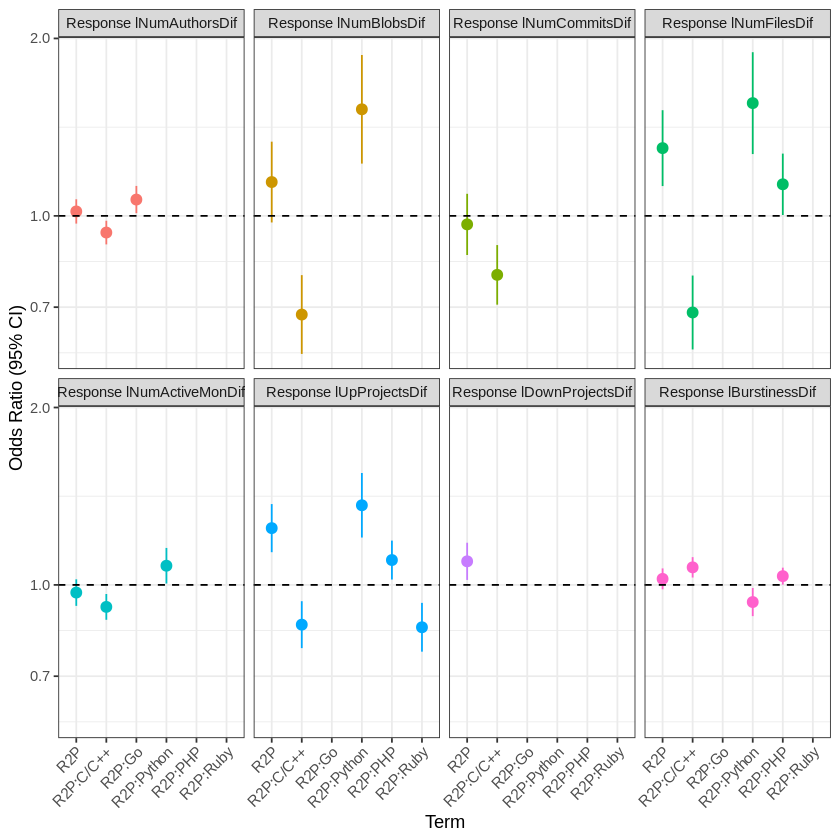

In [9]:
library(dplyr)
library(ggplot2)

alpha <- 1 - confidence
z_crit <- qnorm(1 - alpha / 2) 

df_plot <- data.frame()

for (s in names(sum)) {
  
  # Extract the coefficients and p-values
  coefs_table <- sum[[s]]$coef
  pvals       <- coefs_table[, 4]
  row_names   <- rownames(coefs_table)
  
  # Always keep R2P if present
  r2p_row <- row_names[row_names == "R2P"]
  
  # Keep only significant interactions of the form R2P:XYZ (p < alpha)
  sig_int_rows <- row_names[
    pvals < alpha & grepl("^R2P:", row_names)
  ]
  
  # Combine the rows we want
  final_keep  <- unique(c(r2p_row, sig_int_rows))
  final_coefs <- coefs_table[final_keep, , drop = FALSE]
  
  # If there's nothing to plot, skip
  if (nrow(final_coefs) == 0) next
  
  # Extract estimates and standard errors
  est <- final_coefs[, 1]
  se  <- final_coefs[, 2]
  
  # Calculate odds ratios and CIs
  or    <- exp(est)
  lower <- exp(est - z_crit * se)
  upper <- exp(est + z_crit * se)
  
  # Build a temporary data frame for plotting
  tmp <- data.frame(
    response = s,
    term     = rownames(final_coefs),
    or       = or,
    lower    = lower,
    upper    = upper
  )
  
  df_plot <- rbind(df_plot, tmp)
}

ggplot(df_plot, aes(x = term, y = or, ymin = lower, ymax = upper, color = response)) +
  geom_pointrange(position = position_dodge(width = 0.5)) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  scale_y_log10() +
  facet_wrap(~ response, nrow = 2, ncol = 4) +
  labs(x = "Term", y = "Odds Ratio (95% CI)") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(legend.position = "none")

# Model 2 years

In [10]:
anov_dif_2f[[2]]


Type III MANOVA Tests: Pillai test statistic
                Df test stat approx F num Df den Df    Pr(>F)    
(Intercept)      1  0.058920   81.666      8  10435 < 2.2e-16 ***
C2               1  0.004583    6.005      8  10435 1.011e-07 ***
Language         7  0.025417    4.756     56  73087 < 2.2e-16 ***
lEarliestCommit  1  0.075407  106.381      8  10435 < 2.2e-16 ***
lLatestCommit    1  0.158091  244.932      8  10435 < 2.2e-16 ***
lDelay           1  0.039196   53.212      8  10435 < 2.2e-16 ***
lDistance        1  0.015842   20.997      8  10435 < 2.2e-16 ***
lprop2           1  0.002419    3.163      8  10435  0.001393 ** 
C2:Language      7  0.018707    3.497     56  73087 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [11]:
confidence <- 0.99
sum <- sum_dif_2f[[2]]

# Loop through responses and collect data
for (s in names(sum)) {
    print(s)
    significant_coefs <- sum[[s]]$coef[sum[[s]]$coef[, 4] < 1-confidence, , drop = FALSE]
    significant_coefs <- significant_coefs[grepl(paste(license_levels, collapse = "|"), rownames(significant_coefs)), , drop = FALSE]
    print(significant_coefs)
}

[1] "Response lNumAuthorsDif"
            Estimate Std. Error   t value    Pr(>|t|)
R2P        0.1152118 0.03971589  2.900901 0.003728687
R2P:C/C++ -0.1149564 0.03992674 -2.879183 0.003995172
[1] "Response lNumBlobsDif"
             Estimate Std. Error   t value     Pr(>|t|)
R2P:C/C++  -0.4763918  0.1207971 -3.943736 8.074614e-05
R2P:Python  0.5747237  0.1485466  3.868979 1.099565e-04
[1] "Response lNumCommitsDif"
             Estimate Std. Error   t value     Pr(>|t|)
R2P:C/C++  -0.3276660 0.09420826 -3.478103 5.070327e-04
R2P:Python  0.4683991 0.11584980  4.043159 5.311475e-05
[1] "Response lNumFilesDif"
             Estimate Std. Error   t value     Pr(>|t|)
R2P         0.4135000  0.1131427  3.654677 2.587684e-04
R2P:C/C++  -0.4682468  0.1137433 -4.116696 3.872997e-05
R2P:Python  0.4094053  0.1398725  2.926989 3.429989e-03
[1] "Response lNumActiveMonDif"
              Estimate Std. Error   t value     Pr(>|t|)
R2P:C/C++  -0.12922054 0.04515507 -2.861706 4.222050e-03
R2P:PHP    -0.09